Enter your WRDS username [Your WRDS username]: xinyuezhang24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\22099\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


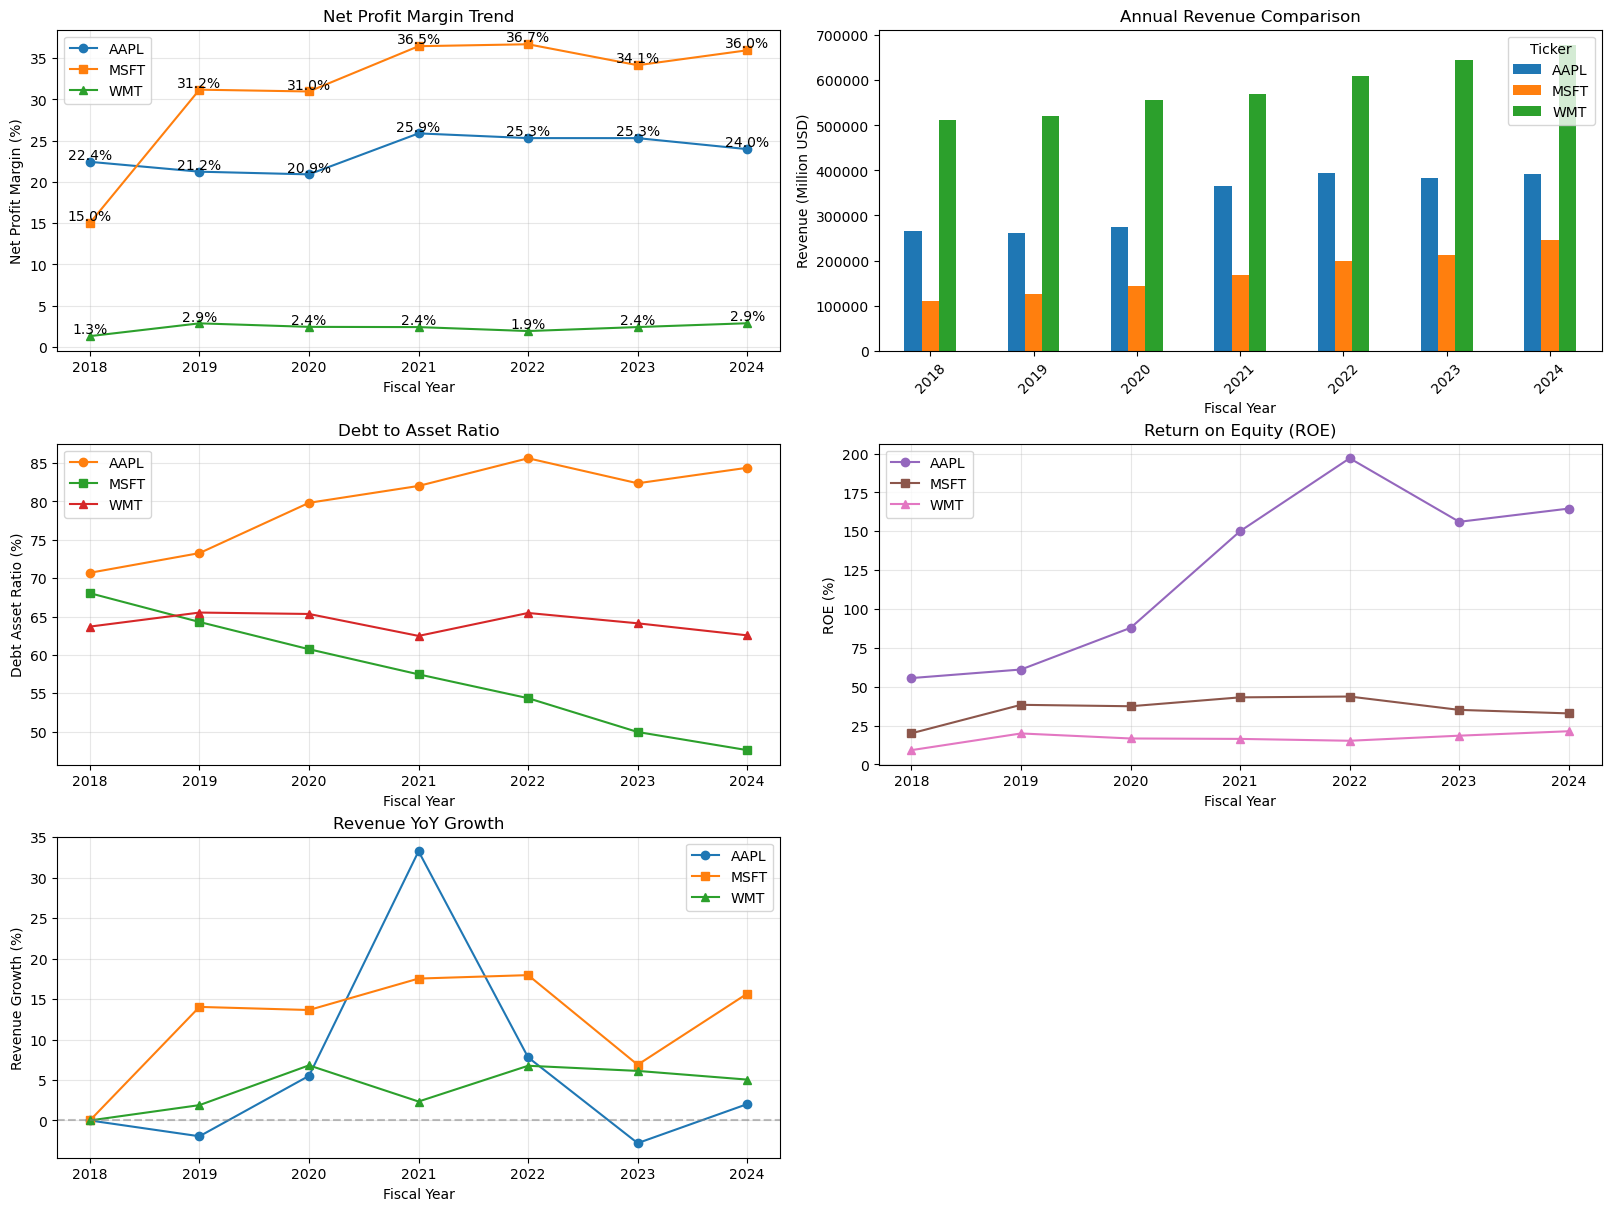

Financial Indicators Descriptive Statistics 2018-2024
      sale                                                               \
     count       mean       std       min       25%       50%       75%   
tic                                                                       
AAPL   7.0  333501.86  63288.21  260174.0  269937.0  365817.0  387160.0   
MSFT   7.0  171801.86  49015.75  110360.0  134429.0  168088.0  205092.5   
WMT    7.0   584658.0  62417.54  511729.0  539179.5  569962.0  627109.0   

                  ni            ... Sale_YoY        NI_YoY                \
           max count      mean  ...      75%    max  count   mean    std   
tic                             ...                                        
AAPL  394328.0   7.0  79630.29  ...     7.22  33.26    6.0  10.15  27.25   
MSFT  245122.0   7.0  56371.14  ...    17.07  17.96    6.0   38.0  50.02   
WMT   678338.0   7.0   13623.0  ...      6.6   6.81    6.0  26.44  50.94   

                                      

In [1]:
# ACC102 WRDS Financial Analysis
import wrds
import pandas as pd
import matplotlib.pyplot as plt

# Connect WRDS database
db = wrds.Connection(wrds_username='Your WRDS username')

# Query firm financial data 2018-2024
sql = """
SELECT tic, fyear, sale, ni, at, lt, ceq
FROM comp.funda
WHERE tic IN ('AAPL','MSFT','WMT')
AND fyear BETWEEN 2018 AND 2024
AND indfmt='INDL' AND datafmt='STD' AND consol='C'
"""
df = db.raw_sql(sql)

# Data cleaning
df['fyear'] = df['fyear'].astype(int)
df = df.drop_duplicates(subset=['tic','fyear'])

# Calculate financial ratios
df['Profit_Margin'] = df['ni'].div(df['sale']) * 100
df['Debt_Asset_Ratio'] = df['lt'].div(df['at']) * 100
df['ROE'] = df['ni'].div(df['ceq']) * 100

# Calculate year-on-year growth
df = df.sort_values(['tic','fyear'])
df['Sale_YoY'] = df.groupby('tic')['sale'].pct_change() * 100
df['NI_YoY'] = df.groupby('tic')['ni'].pct_change() * 100

# Pivot table & handle missing values
df_pivot = df.pivot(index='fyear', columns='tic', values='Profit_Margin').fillna(0)
da_pivot = df.pivot(index='fyear', columns='tic', values='Debt_Asset_Ratio').fillna(0)
roe_pivot = df.pivot(index='fyear', columns='tic', values='ROE').fillna(0)
yoy_sale_pivot = df.pivot(index='fyear', columns='tic', values='Sale_YoY').fillna(0)

# Create multi-subplot figure
fig, axes = plt.subplots(3, 2, figsize=(16, 12), constrained_layout=True)

# Plot1: Net Profit Margin with value labels
ax1 = axes[0,0]
ax1.plot(df_pivot.index, df_pivot['AAPL'], marker='o', label='AAPL')
ax1.plot(df_pivot.index, df_pivot['MSFT'], marker='s', label='MSFT')
ax1.plot(df_pivot.index, df_pivot['WMT'], marker='^', label='WMT')

# Add data annotations
for year in df_pivot.index:
    ax1.text(year, df_pivot.loc[year,'AAPL']+0.3, f"{df_pivot.loc[year,'AAPL']:.1f}%", ha='center')
    ax1.text(year, df_pivot.loc[year,'MSFT']+0.3, f"{df_pivot.loc[year,'MSFT']:.1f}%", ha='center')
    ax1.text(year, df_pivot.loc[year,'WMT']+0.3, f"{df_pivot.loc[year,'WMT']:.1f}%", ha='center')

ax1.set_title("Net Profit Margin Trend", fontsize=12)
ax1.set_xlabel("Fiscal Year")
ax1.set_ylabel("Net Profit Margin (%)")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot2: Annual Revenue Comparison
ax2 = axes[0,1]
sale_pivot = df.pivot(index='fyear', columns='tic', values='sale').fillna(0)
sale_pivot.plot(kind='bar', ax=ax2)
ax2.set_title("Annual Revenue Comparison")
ax2.set_xlabel("Fiscal Year")
ax2.set_ylabel("Revenue (Million USD)")
ax2.legend(title='Ticker')
ax2.tick_params(axis='x', rotation=45)

# Plot3: Debt to Asset Ratio Trend
ax3 = axes[1,0]
ax3.plot(da_pivot.index, da_pivot['AAPL'], marker='o', label='AAPL', color='#ff7f0e')
ax3.plot(da_pivot.index, da_pivot['MSFT'], marker='s', label='MSFT', color='#2ca02c')
ax3.plot(da_pivot.index, da_pivot['WMT'], marker='^', label='WMT', color='#d62728')
ax3.set_title("Debt to Asset Ratio")
ax3.set_xlabel("Fiscal Year")
ax3.set_ylabel("Debt Asset Ratio (%)")
ax3.legend()
ax3.grid(alpha=0.3)

# Plot4: ROE Trend
ax4 = axes[1,1]
ax4.plot(roe_pivot.index, roe_pivot['AAPL'], marker='o', label='AAPL', color='#9467bd')
ax4.plot(roe_pivot.index, roe_pivot['MSFT'], marker='s', label='MSFT', color='#8c564b')
ax4.plot(roe_pivot.index, roe_pivot['WMT'], marker='^', label='WMT', color='#e377c2')
ax4.set_title("Return on Equity (ROE)")
ax4.set_xlabel("Fiscal Year")
ax4.set_ylabel("ROE (%)")
ax4.legend()
ax4.grid(alpha=0.3)

# Plot5: Revenue YoY Growth Rate
ax5 = axes[2,0]
ax5.plot(yoy_sale_pivot.index, yoy_sale_pivot['AAPL'], marker='o', label='AAPL')
ax5.plot(yoy_sale_pivot.index, yoy_sale_pivot['MSFT'], marker='s', label='MSFT')
ax5.plot(yoy_sale_pivot.index, yoy_sale_pivot['WMT'], marker='^', label='WMT')
ax5.set_title("Revenue YoY Growth")
ax5.set_xlabel("Fiscal Year")
ax5.set_ylabel("Revenue Growth (%)")
ax5.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax5.legend()
ax5.grid(alpha=0.3)

axes[2,1].axis('off')
plt.show()

# Descriptive statistics summary
print("="*80)
print("Financial Indicators Descriptive Statistics 2018-2024")
print(df.groupby('tic')[['sale','ni','Profit_Margin','Debt_Asset_Ratio','ROE','Sale_YoY','NI_YoY']].describe().round(2))
print("="*80)

# Close database connection
db.close()